# Cellula — Week 1 — Task 2: LSTM for Toxic Text Classification

**Goal:** Classify text into one of 9 safety/toxicity categories.

**Metric:** F1 score, with a target of **F1 ≥ 0.85**.

## Part 1 — Load the dataset

In [ ]:
import pandas as pd

df = pd.read_csv("data/cellula_toxic_data.csv")
df.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [3]:
df.shape

(3000, 3)

## Part 2 — Check the Toxic Categories

In [4]:
df["Toxic Category"].value_counts()

,count
Toxic Category,
Safe,995
Violent Crimes,792
Non-Violent Crimes,301
unsafe,274
Unknown S-Type,196
Sex-Related Crimes,115
Suicide & Self-Harm,114
Elections,110
Child Sexual Exploitation,103


## Part 3 — Missing values

In [5]:
df.isnull().sum()

,0
query,0
image descriptions,0
Toxic Category,0


## Part 4 — Use query and image descriptions together

- The image descriptions have only a few different values.
- Some descriptions are linked to one category, while others are shared between different categories.
- So, I will use both the query and the image description as the input text.


In [6]:
pd.crosstab(
    df["image descriptions"],
    df["Toxic Category"]
)

Toxic Category,Child Sexual Exploitation,Elections,Non-Violent Crimes,Safe,Sex-Related Crimes,Suicide & Self-Harm,Unknown S-Type,Violent Crimes,unsafe
image descriptions,,,,,,,,,
A child playing in a sunny meadow.,40,38,0,342,43,40,69,0,0
A dark alley with graffiti and broken glass.,0,0,0,0,0,0,0,0,93
A family enjoying a picnic in the park.,30,36,0,321,40,42,59,0,0
A masked individual in a threatening posture.,0,0,0,0,0,0,0,0,91
A masked person tampering with an ATM.,0,0,100,0,0,0,0,0,0
A person discreetly using a laptop in a dim room.,0,0,117,0,0,0,0,0,0
A shadowy figure holding a weapon in a dimly lit room.,0,0,0,0,0,0,0,229,0
An emergency vehicle with flashing lights at a violent incident.,0,0,0,0,0,0,0,288,0
People walking through a peaceful city street.,33,36,0,332,32,32,68,0,0


So I'll combine both columns into one `text` input:

In [7]:
df["text"] = df["query"] + " " + df["image descriptions"]

X = df["text"]
y = df["Toxic Category"]

## Part 5 — Train / test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 2400
Test samples: 600


## Part 6 — Tokenization


**6.1 Create the tokenizer**

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

**6.2 Fit the tokenizer ONLY on training data** (the test set must never leak into the vocabulary)

In [10]:
tokenizer.fit_on_texts(X_train)

**6.3 Vocabulary size**

In [11]:
print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 3979


**6.4 Convert text into sequences**

In [12]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print(X_train.iloc[0])
print(X_train_sequences[0])

What are the health benefits of daily exercise for safe individuals? A child playing in a sunny meadow.
[9, 11, 5, 13, 17, 8, 16, 18, 7, 85, 14, 2, 15, 25, 4, 2, 28, 29]


## Part 7 — Padding

Pad every sequence to the same length so they fit in one array.

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 50

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

print("Training shape:", X_train_padded.shape)

Training shape: (2400, 50)


## Part 8 — Encode the labels

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']


## Part 9 — Validation split and class weights

In [15]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_train_encoded
)

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_padded.shape)

Training: (1920, 50)
Validation: (480, 50)
Test: (600, 50)


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
classes = np.unique(y_train_final)
class_weights_array = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_final)
class_weights = dict(zip(classes, class_weights_array))
print(class_weights)

{np.int64(0): np.float64(3.2323232323232323), np.int64(1): np.float64(3.0476190476190474), np.int64(2): np.float64(1.1053540587219344), np.int64(3): np.float64(0.3349031920460492), np.int64(4): np.float64(2.8828828828828827), np.int64(5): np.float64(2.922374429223744), np.int64(6): np.float64(1.7066666666666668), np.int64(7): np.float64(0.42077580539119), np.int64(8): np.float64(1.2190476190476192)}


## Part 10 — Build the LSTM


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

In [20]:
vocab_size = len(tokenizer.word_index) + 1
num_classes = len(label_encoder.classes_)

print("Vocabulary size:", vocab_size)
print("Number of classes:", num_classes)

Vocabulary size: 3980
Number of classes: 9


In [21]:
model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │       509,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561,225 (2.14 MB)

 Trainable params: 561,225 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## Part 11 — Train the model

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [24]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4849 - loss: 1.7847 - val_accuracy: 0.7646 - val_loss: 0.8486
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8672 - loss: 0.7549 - val_accuracy: 0.9667 - val_loss: 0.2493
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9542 - loss: 0.2564 - val_accuracy: 0.9708 - val_loss: 0.1410
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9797 - loss: 0.1062 - val_accuracy: 0.9563 - val_loss: 0.1425
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9937 - loss: 0.0522 - val_accuracy: 0.9500 - val_loss: 0.1761
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9932 - loss: 0.0325 - val_accuracy: 0.9417 - val_loss: 0.2349


## Part 12 — Evaluate on the test set

In [25]:
y_pred_prob = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_prob, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [26]:
from sklearn.metrics import f1_score

f1_weighted = f1_score(y_test_encoded, y_pred, average="weighted")
f1_macro = f1_score(y_test_encoded, y_pred, average="macro")

print("Weighted F1 Score:", f1_weighted)
print("Macro F1 Score:", f1_macro)
print("Target for this task: F1 >=", 0.85)

Weighted F1 Score: 0.9543788762461344
Macro F1 Score: 0.9515052641399231
Target for this task: F1 >= 0.85


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

                           precision    recall  f1-score   support

Child Sexual Exploitation       1.00      1.00      1.00        21
                Elections       1.00      1.00      1.00        22
       Non-Violent Crimes       0.98      1.00      0.99        60
                     Safe       0.91      0.98      0.94       199
       Sex-Related Crimes       1.00      1.00      1.00        23
      Suicide & Self-Harm       1.00      1.00      1.00        23
           Unknown S-Type       0.87      0.51      0.65        39
           Violent Crimes       1.00      0.99      0.99       158
                   unsafe       0.98      1.00      0.99        55

                 accuracy                           0.96       600
                macro avg       0.97      0.94      0.95       600
             weighted avg       0.96      0.96      0.95       600



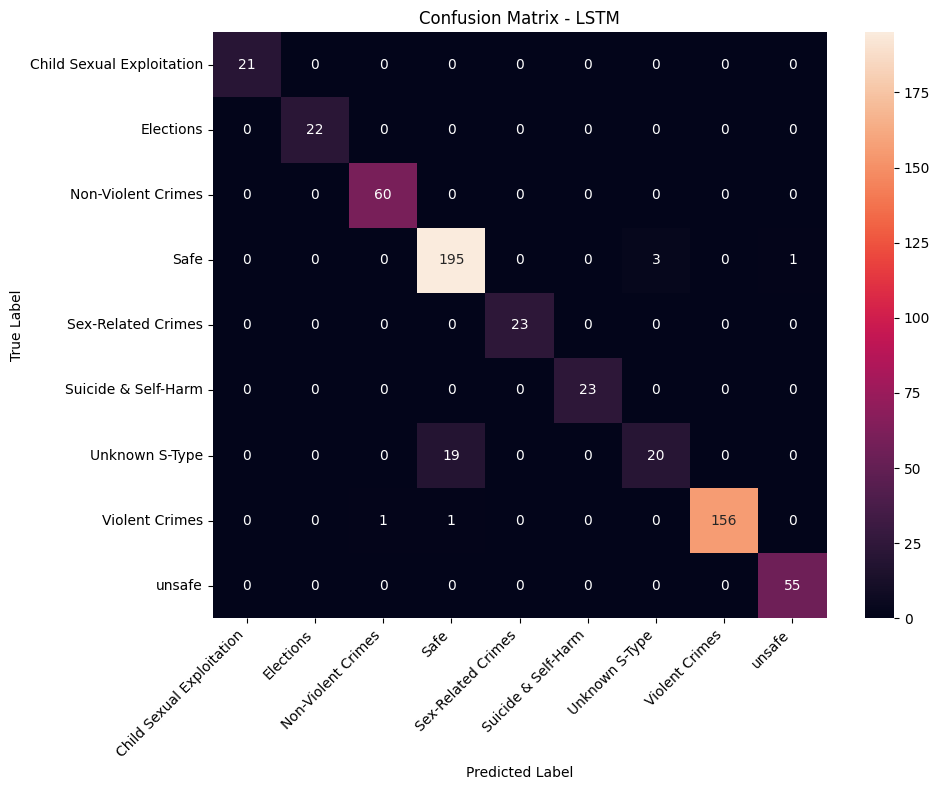

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Part 13 — Training curves

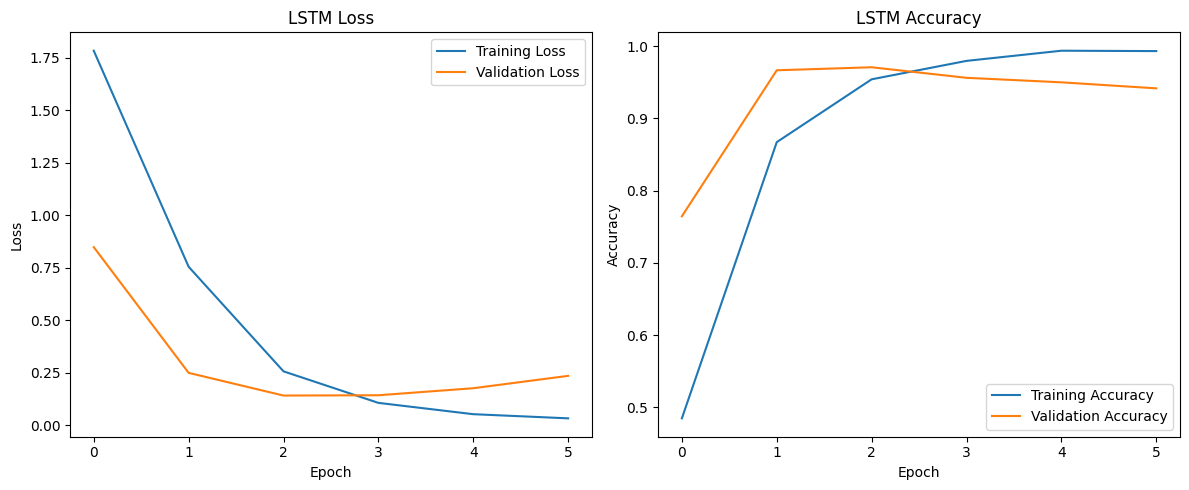

In [31]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Part 14 — Export a PDF report


In [32]:
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.7 MB/s eta 0:00:00


In [33]:
import io
from PIL import Image as PILImage

def save_plot(fig, filename):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)
    PILImage.open(buf).save(filename)
    buf.close()

fig_hist, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("LSTM Loss History"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Training Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("LSTM Accuracy History"); axes[1].legend()
plt.tight_layout()
save_plot(fig_hist, "lstm_history.png")
plt.close(fig_hist)

fig_cm = plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - LSTM"); plt.xticks(rotation=45, ha="right"); plt.tight_layout()
save_plot(fig_cm, "lstm_confusion_matrix.png")
plt.close(fig_cm)

print("Plots saved.")

Plots saved.


In [34]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

styles = getSampleStyleSheet()

def generate_report(filename="LSTM_Training_Report.pdf"):
    doc = SimpleDocTemplate(filename, pagesize=letter)
    story = [Paragraph("LSTM Model Evaluation Report", styles["h1"]), Spacer(1, 0.2 * inch)]
    story.append(Paragraph(
        "Task 2: target F1 &gt;= 0.85.",
        styles["Normal"],
    ))
    story.append(Spacer(1, 0.2 * inch))

    story.append(Paragraph("<u><b>LSTM Performance</b></u>", styles["h2"]))
    story.append(Spacer(1, 0.1 * inch))
    story.append(Paragraph(f"<b>Weighted F1 Score:</b> {f1_weighted:.4f}", styles["Normal"]))
    story.append(Paragraph(f"<b>Macro F1 Score:</b> {f1_macro:.4f}", styles["Normal"]))
    story.append(Paragraph(f"<b>Target (F1 &gt;= 0.85):</b> {'PASSED' if f1_weighted >= 0.85 else 'NOT MET'}", styles["Normal"]))
    story.append(Spacer(1, 0.1 * inch))

    report_text = classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_)
    story.append(Paragraph("<b>Classification Report:</b>", styles["Normal"]))
    story.append(Paragraph(
        '<font face="Courier">' + report_text.replace("\n", "<br/>").replace(" ", "&nbsp;") + "</font>",
        styles["Normal"],
    ))
    story.append(Spacer(1, 0.2 * inch))
    story.append(Image("lstm_confusion_matrix.png", width=4 * inch, height=3.25 * inch))
    story.append(Spacer(1, 0.2 * inch))
    story.append(Image("lstm_history.png", width=6 * inch, height=3 * inch))

    doc.build(story)
    print(f"Report '{filename}' generated successfully.")

generate_report()

Report 'LSTM_Training_Report.pdf' generated successfully.


## Conclusion

The LSTM model achieved a good result on the toxic text classification task. It achieved a Weighted F1 Score of 0.9544 and a Macro F1 Score of 0.9515, which are both higher than the required 0.85.

Compared with the RNN model, the LSTM achieved a higher F1 score on the test set. The RNN achieved a Weighted F1 Score of 0.9225, while the LSTM achieved 0.9544.

The LSTM was able to classify most of the categories correctly, and the confusion matrix helped show where the model made mistakes.
